<div>
<img src="https://www.smu.edu.sg/themes/smubase_5g/assets/site-headers/logo-smu-d.svg?revised=20240229" width="200" align="center">
</div>

# Predicting Residential House Prices in Ames, Iowa
### ACCT682 Programming for Business Analytics — Team Project

**Group / class section:** *G#*

| Team member (alphabetical) | Student ID |
| --- | --- |
| *Andersen, Marius* | *ID* |
| *Clarysse Jelke* | *ID* |
| *name* | *ID* |
| *Kukreja, Siddharth Yash* | *ID* |

**Instructor:** Dr Wang Jiwei  |  **Submitted:** August 2026

---

Runs end to end in about two minutes; the hyperparameter grids in sections 5.3 to 5.5 are the slow part. `train.csv` and `test.csv` sit in the same folder as this notebook, so every path is relative.

> *Before submitting: fill in the names, IDs and group number above, and rename the file to `ACCT682_G#_HousePrices.ipynb` as the instructions require.*

# 1. Introduction

*To write, ~4 paragraphs:*
- *the business problem, and why 79 recorded attributes should be enough to price a house*
- *the data: 1,460 labelled sales, 1,459 unlabelled, Ames Iowa 2006-2010 (De Cock, 2011)*
- *the metric: RMSE on log(SalePrice), so a 10% error costs the same on a cheap house as an expensive one*
- *preview: which cleaning decision mattered most, which models we used, final score*

Source: Kaggle, *House Prices - Advanced Regression Techniques*.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, RidgeCV, LassoCV
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(f"train: {train.shape}, test: {test.shape}")
print(train.dtypes.value_counts())

train: (1460, 81), test: (1459, 80)
object     43
int64      35
float64     3
Name: count, dtype: int64


# 2. Exploratory data analysis

## 2.1 The target

*As shown in the figure below, sale prices are heavily right-skewed, with a skewness of 1.88. This indicates that a small number of high-priced homes, well beyond the typical price range, are pulling the distribution to the right. In a skewed distribution, the mean and median diverge,the mean is pulled toward the extreme values, while the median remains a more representative measure of the “typical” home price.*

*This skew can create challenges for regression modelling. Many regression models are trained using squared-error loss, which penalizes large errors disproportionately more than small ones. As a result, the small number of high-priced homes can have a strong influence on the loss function, shifting the model’s focus away from the broader market and making it more sensitive to extreme values.*

*To address this, we applied a log transformation to sales price , reducing skewness from 1.88 to 0.12 and producing a much more symmetric distribution that may be better suited for modelling. This transformation reduces the relative influence of extreme prices and may support more reliable and generalizable predictions in future modelling.*


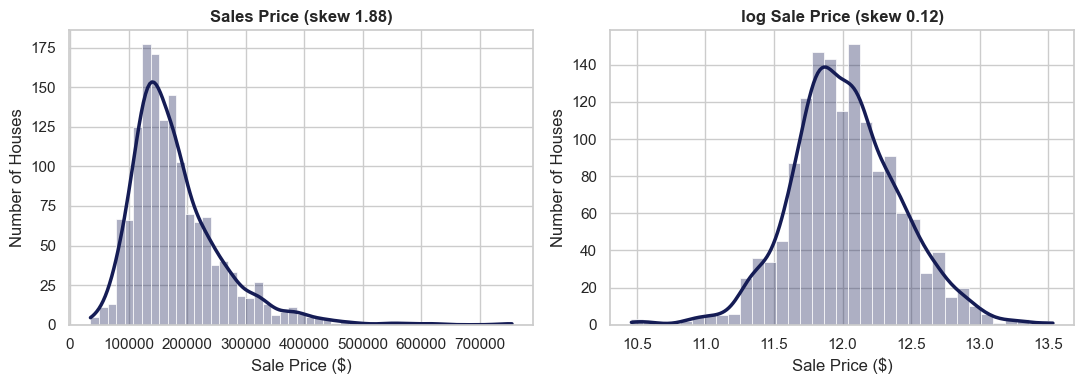

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train["SalePrice"], kde=True, color = "#151C55", alpha=0.35,  edgecolor="white", linewidth=0.5, ax=ax[0],  line_kws={"color": "#C69200", "linewidth": 2.5})
ax[0].set_title(f'Sales Price (skew {train["SalePrice"].skew():.2f})', fontsize=12, fontweight="bold")
ax[0].set_xlabel("Sale Price ($)")
ax[0].set_ylabel("Number of Houses")

sns.histplot(np.log(train["SalePrice"]), color = "#151C55", alpha=0.35,edgecolor="white", linewidth=0.5,line_kws={"color": "#C69200", "linewidth": 2.5}, kde=True, ax=ax[1])
ax[1].set_title(f'log Sale Price (skew {np.log(train["SalePrice"]).skew():.2f})', fontsize=12,  fontweight="bold")
ax[1].set_xlabel("Sale Price ($)")
ax[1].set_ylabel("Number of Houses")
plt.tight_layout()

## 2.2 Missing values

*There are 34 columns with missing data. However, as shown in the figure below, the majority of these missing values represent the absence of a feature, such as a pool, garage, or fence, rather than a genuine data collection error. For example, a missing value in PoolQC simply indicates the property does not have a pool, and a missing value in GarageType indicates the property does not have a garage.*

*Given this, we treat most of these missing values as a meaningful category,  labeling them as "None" rather than imputing them statistically. Imputing these values would incorrectly suggest the feature exists but was unrecorded, when in fact the absence itself is informative and should be preserved as-is.*

count    34.000000
mean     15.826331
std      31.314324
min       0.034258
25%       0.034258
50%       1.747174
75%       5.447071
max      99.657417
dtype: float64

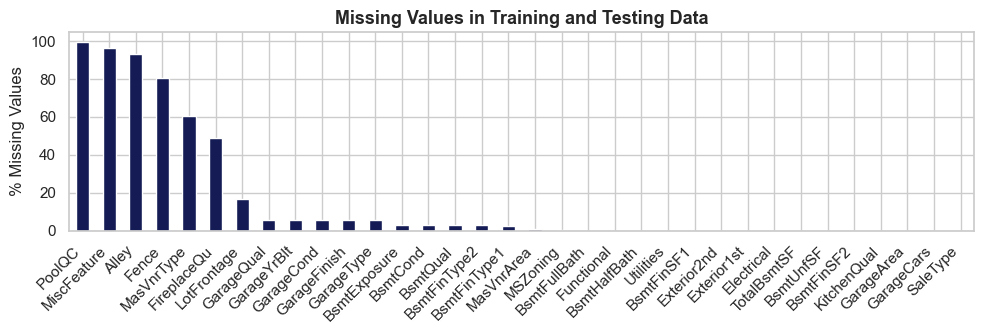

In [ ]:
# train and test together, since test has gaps train does not
all_raw = pd.concat([train.drop(columns=["SalePrice"]), test], ignore_index=True)

missing = all_raw.isnull().sum()
missing = (missing[missing > 0] / len(all_raw) * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 3.5))
missing.plot(kind="bar", color="#151C55")
plt.ylabel("% Missing Values")
plt.title("Missing Values in Training and Testing Data", fontsize=13, fontweight="bold")
plt.xlabel("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
missing.describe()

To confirm that missing values represent genuine absence rather than data collection errors, we cross-referenced the categorical column against its corresponding size/quantity feature (e.g. PoolQC vs. PoolArea). In each case, the count of blank entries closely matched the count of properties with a size value of zero. With only a small number of mismatches. This confirms these are structurally missing rather than randomly missing data, which supports our decision to encode them as "None" rather than statistically impute them. Thus, we fill these with `"None"` and the matching area columns with `0`.

In [ ]:
# is a blank really "this house does not have one"? check against the matching size column
for cat, size in {"PoolQC": "PoolArea", "GarageType": "GarageArea", "BsmtQual": "TotalBsmtSF",
                  "FireplaceQu": "Fireplaces", "MasVnrType": "MasVnrArea"}.items():
    blank = all_raw[cat].isna()
    both = (blank & (all_raw[size].fillna(0) == 0)).sum()
    print(f"{cat:12s} blank: {blank.sum():5d}   of those with {size} = 0: {both:5d}")

PoolQC       blank:  2909   of those with PoolArea = 0:  2906
GarageType   blank:   157   of those with GarageArea = 0:   157
BsmtQual     blank:    81   of those with TotalBsmtSF = 0:    79
FireplaceQu  blank:  1420   of those with Fireplaces = 0:  1420
MasVnrType   blank:  1766   of those with MasVnrArea = 0:  1758


*To check whether frontage is consistent across the dataset or varies by neighbourhood, we plot LotFrontage by neighbourhood and compare medians. The overall median is 68 feet, but neighbourhood medians range from 21 to 92 feet, filling every missing value with a single overall median would badly misrepresent streets on either end of that range. We therefore impute LotFrontage using the median of its own neighbourhood, rather than a single dataset-wide value, and use the median rather than the mean because lot sizes are right-skewed.*

overall median 68, neighbourhood medians 21 to 92


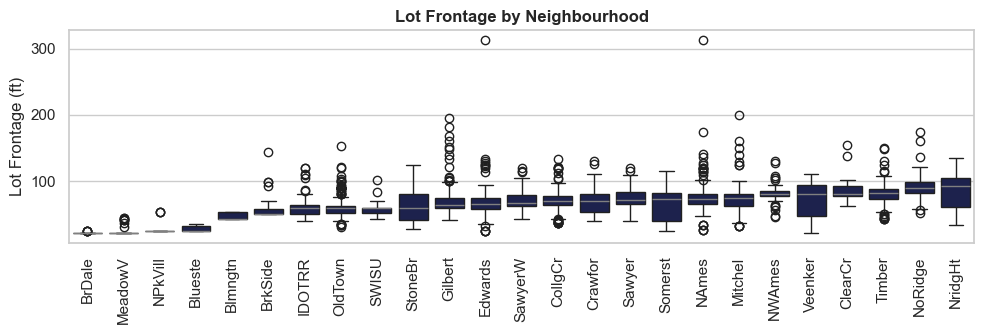

In [ ]:
# LotFrontage is the one column where we have to guess a number
plt.figure(figsize=(10, 3.5))
order = all_raw.groupby("Neighborhood")["LotFrontage"].median().sort_values().index
sns.boxplot(data=all_raw, x="Neighborhood", y="LotFrontage", order=order, color="#151C55",  medianprops={"color": "grey", "linewidth": 1} )
plt.xticks(rotation=90); plt.title("Lot Frontage by Neighbourhood", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("Lot Frontage (ft)")
plt.tight_layout()

nbhd = all_raw.groupby("Neighborhood")["LotFrontage"].median()
print(f"overall median {all_raw.LotFrontage.median():.0f}, neighbourhood medians {nbhd.min():.0f} to {nbhd.max():.0f}")

*We impute LotFrontage with the median of its own neighbourhood. The medians printed above run from 21 to 92 feet against an overall median of 68, so filling every missing value with a single dataset-wide figure would be badly wrong for some streets. We use the median rather than the mean because lot sizes are right-skewed, and the median is less distorted by a handful of unusually large lots.*

## 2.3 Categorical variables

*Next, we explore the categorical columns in more detail. Of the 79 columns, 43 are categorical, and none has more than 25 levels, so one-hot encoding stays manageable rather than exploding into an unwieldy number of dummy variables.*

*Neighborhood is the strongest categorical predictor of the group. The boxplot below spans a median price range from 88,000 to 315,000 depending on location alone. Several other categorical columns, like KitchenQual, carry a genuine order in their quality grades, as their medians show. We tested encoding that order explicitly and it made no difference to model performance (Section 3), so we let one-hot encoding handle these columns as well rather than adding ordinal complexity*

*The KitchenQual medians confirm a genuine order**

In [ ]:
# are the quality grades really ordered?
train.groupby("KitchenQual")["SalePrice"].median().sort_values().round(0)

KitchenQual
Fa    115000.0
TA    137000.0
Gd    201400.0
Ex    316750.0
Name: SalePrice, dtype: float64

*We check how many categorical columns there are, their maximum number of levels, whether any rare categories that need special handling before one-hot encoding.*

In [ ]:
cats = all_raw.select_dtypes(include=[object])
print(f"{cats.shape[1]} categorical columns, at most {cats.nunique().max()} levels\n")
print(all_raw["Utilities"].value_counts(dropna=False))

43 categorical columns, at most 25 levels

Utilities
AllPub    2916
NaN          2
NoSeWa       1
Name: count, dtype: int64


`Utilities` has one non-`AllPub` house in the whole dataset, so it can only add noise. We drop it.

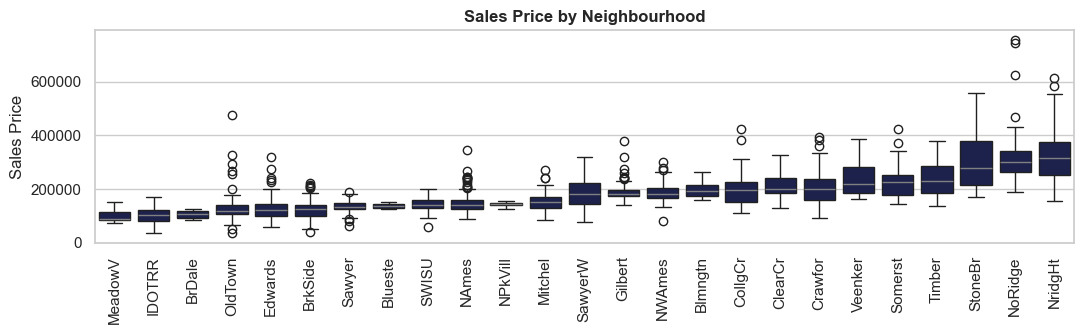

In [ ]:
plt.figure(figsize=(11, 3.5))
order = train.groupby("Neighborhood")["SalePrice"].median().sort_values().index
sns.boxplot(data=train, x="Neighborhood", y="SalePrice", order=order, color="#151C55",  medianprops={"color": "grey", "linewidth": 1})
plt.xticks(rotation=90); plt.title("Sales Price by Neighbourhood", fontsize=12, fontweight="bold")
plt.xlabel("")
plt.ylabel("Sales Price")
plt.tight_layout()

## 2.4 Correlations

*`OverallQual` (0.79) and `GrLivArea` (0.71) are by far the strongest predictors of `SalePrice`, confirming that quality rating and living area size are the two dominant drivers of price. Garage size (`GarageCars` 0.64, `GarageArea` 0.62), basement/first-floor size, and bathroom/room counts follow at a moderate strength (0.5–0.6).*

*The heatmap also reveals several predictor pairs that are highly correlated with *each other*, not just with price: `GarageCars` and `GarageArea` (0.88), `TotalBsmtSF` and `1stFlrSF` (0.82), `GrLivArea` and `TotRmsAbvGrd` (0.83), and `YearBuilt` and `GarageYrBlt` (0.83). This overlap means several features carry largely redundant information, a form of multicollinearity that can destabilize coefficient estimates in linear models such as OLS, motivating the use of regularized approaches (Ridge, Lasso) later in the modelling stage.*

SalePrice       1.000
OverallQual     0.791
GrLivArea       0.709
GarageCars      0.640
GarageArea      0.623
TotalBsmtSF     0.614
1stFlrSF        0.606
FullBath        0.561
TotRmsAbvGrd    0.534
YearBuilt       0.523
YearRemodAdd    0.507
GarageYrBlt     0.486


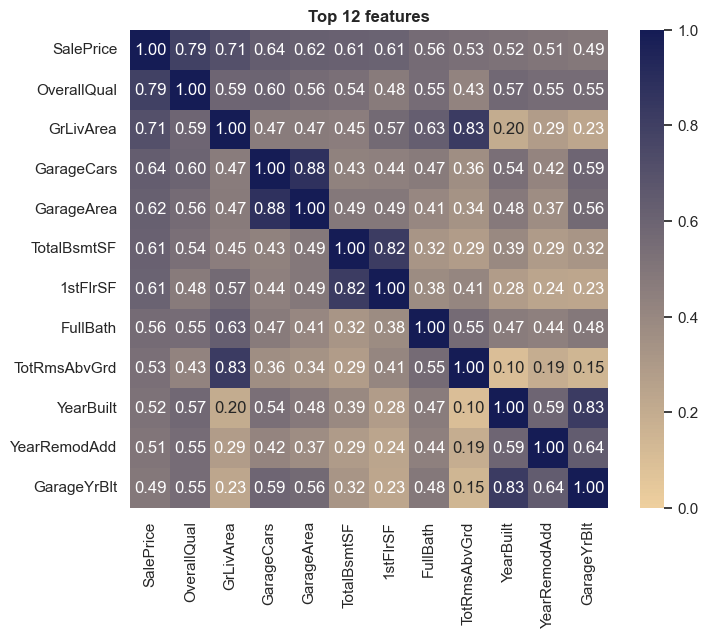

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

corr = train.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)
print(corr.head(12).round(3).to_string())
top = corr.head(12).index

smu_branding = LinearSegmentedColormap.from_list(
    "brand_diverging",
    ["#C0392B", "#EFD09E", "#151C55"]  # red -> gold -> navy
)

plt.figure(figsize=(8, 6.5))
sns.heatmap(train[top].corr(), annot=True, fmt=".2f", cmap=smu_branding, center=0,vmin=0, square=True)
plt.title("Top 12 features",fontsize=12, fontweight="bold" ); plt.tight_layout()

In [ ]:
# which predictors are near-duplicates of each other?
num = train.select_dtypes(include=[np.number]).drop(columns=["Id", "SalePrice"])
cm = num.corr().abs()
pairs = cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool)).stack()
pairs[pairs > 0.8].sort_values(ascending=False).round(2)

GarageCars   GarageArea      0.88
YearBuilt    GarageYrBlt     0.83
GrLivArea    TotRmsAbvGrd    0.83
TotalBsmtSF  1stFlrSF        0.82
dtype: float64

*Several predictors carry almost the same information. This is the reason plain OLS struggles later and the reason we reach for penalised regression: with near-duplicate columns the coefficients are barely identified, so they swing wildly between folds.*

*We therefore check the strongest predictors below.*

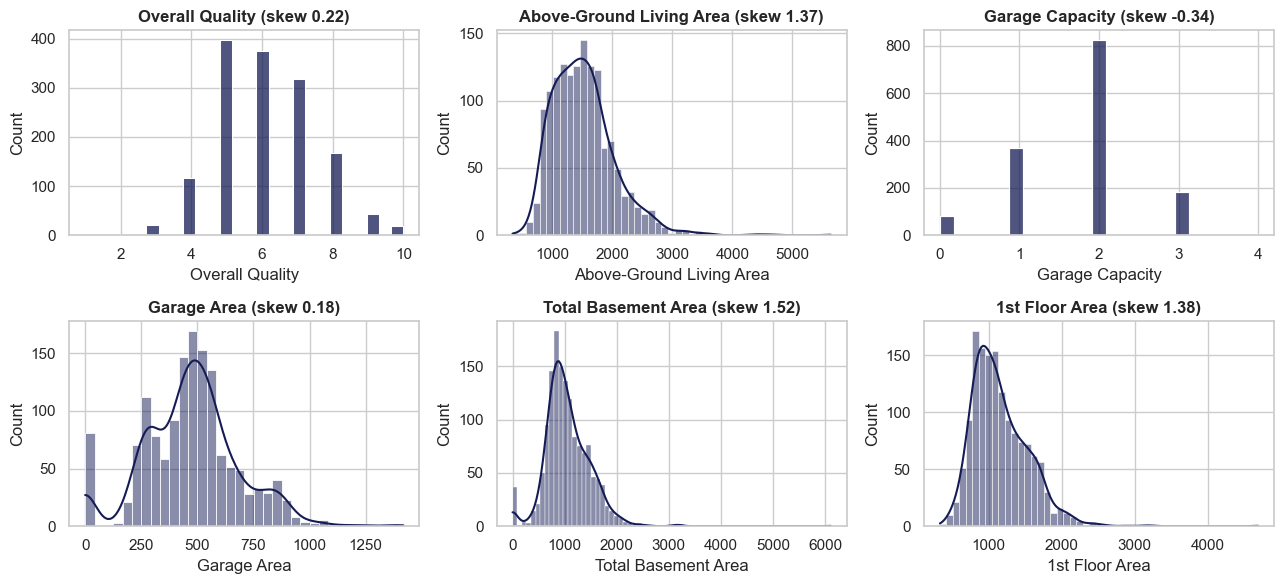

In [ ]:
# distributions of the strongest numeric predictors
top6 = [c for c in corr.head(8).index if c != "SalePrice"][:6]

fig, ax = plt.subplots(2, 3, figsize=(13, 6))
for i, (a, col) in enumerate(zip(ax.ravel(), top6)):
    show_kde = i not in (0, 2)
    sns.histplot(train[col], kde=show_kde, ax=a, color = "#151C55")
    ax[0, 0].set_title(f"Overall Quality (skew {train['OverallQual'].skew():.2f})", fontweight="bold", fontsize=12)
ax[0, 1].set_title(f"Above-Ground Living Area (skew {train['GrLivArea'].skew():.2f})", fontweight="bold", fontsize=12)
ax[0, 2].set_title(f"Garage Capacity (skew {train['GarageCars'].skew():.2f})", fontweight="bold", fontsize=12)
ax[1, 0].set_title(f"Garage Area (skew {train['GarageArea'].skew():.2f})", fontweight="bold", fontsize=12)
ax[1, 1].set_title(f"Total Basement Area (skew {train['TotalBsmtSF'].skew():.2f})", fontweight="bold", fontsize=12)
ax[1, 2].set_title(f"1st Floor Area (skew {train['1stFlrSF'].skew():.2f})", fontweight="bold", fontsize=12)
# set each x-label individually
ax[0, 0].set_xlabel("Overall Quality")
ax[0, 1].set_xlabel("Above-Ground Living Area")
ax[0, 2].set_xlabel("Garage Capacity")
ax[1, 0].set_xlabel("Garage Area")
ax[1, 1].set_xlabel("Total Basement Area")
ax[1, 2].set_xlabel("1st Floor Area")
plt.tight_layout()

*Several of the strongest predictors are themselves skewed, for the same reason `SalePrice` was: a small number of large or unusual properties stretch the distribution. `GrLivArea` (skew 1.37), `TotalBsmtSF` (1.52), and `1stFlrSF` (1.38) all show a similar right-skewed shape, so we log these in section 3 for the same reason we log the target — to stabilise variance and reduce the influence of extreme values on squared-error loss.*

*`OverallQual`, `GarageCars`, and `GarageArea` are close to symmetric already and are left as-is.*

*The spikes at zero in `TotalBsmtSF` and `GarageArea` are houses that simply don't have a basement or garage, not missing or erroneous values, which is consistent with what we saw in section 2.2.*

## 2.5 Outliers

*Four houses have `GrLivArea` above 4,000 sq ft. Two sold cheap (under $200,000) despite `OverallQual` of 10, both are `Partial` sales, meaning the house was sold before it was finished, so the price does not reflect a completed home. The other two sold for over $700,000, as expected for their size and quality (`Normal` and `Abnorml`).*

*We drop the two `Partial` sales (`GrLivArea > 4000` and `SalePrice < 300000`), and keep the two expensive ones.*

*This threshold is not something we chose ourselves, but we base it off of De Cock (2011), the author of the dataset, recommends removing houses above 4,000 square feet* 

*We keep the other unusual sales, `Abnorml` and `Family`, because the test set contains these sale conditions too.*

,Id,GrLivArea,SalePrice,OverallQual,SaleCondition
523,524,4676,184750,10,Partial
691,692,4316,755000,10,Normal
1182,1183,4476,745000,10,Abnorml
1298,1299,5642,160000,10,Partial


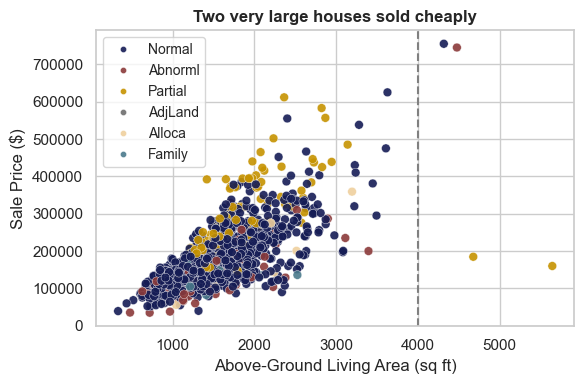

In [ ]:
brand_palette = {
    "Normal":  "#151C55",  
    "Partial": "#C69200",  
    "Abnorml": "#8B3A3A",  
    "Family":  "#4A7A8C",  
    "Alloca":  "#EFD09E",  
    "AdjLand": "#6E6E6E",  
}
plt.figure(figsize=(6, 4))
sns.scatterplot(data=train, x="GrLivArea", y="SalePrice", hue="SaleCondition", palette=brand_palette, s=40, alpha=0.9, edgecolor="white", linewidth=0.3 )
plt.axvline(4000, ls="--", c="grey")
plt.title("Two very large houses sold cheaply",  fontweight="bold", fontsize=12 )
plt.legend(loc="upper left", fontsize="small", markerscale=0.7)
plt.xlabel("Above-Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.tight_layout()
train.loc[train.GrLivArea > 4000, ["Id", "GrLivArea", "SalePrice", "OverallQual", "SaleCondition"]]

*We drop the two with `GrLivArea > 4000` **and** `SalePrice < 300000`.
Both are `Partial` sales — the two expensive large houses stay. This follows De Cock's published recommendation rather than a threshold we tuned ourselves.*

# 3. Data cleaning

We clean train and test together so the same rules apply to both. The target is never involved, so nothing about SalePrice leaks.

An earlier version acted on the findings in 2.2 and 2.3 in detail: 15 columns filled with `"None"`, 10 with `0`, `LotFrontage` by neighbourhood median, and 21 quality columns mapped onto ordered integers — about 52 lines. We replaced all of it with one rule, median for numbers and most common value for labels, and submitted both:

| | Careful encoding | One blunt rule |
| --- | --- | --- |
| Lines of cleaning code | 52 | 6 |
| Encoded columns | 246 | 309 |
| Lasso, CV | 0.1120 | **0.1099** |
| Average of four, CV | 0.1068 | **0.1065** |
| Average of four, **Kaggle** | **0.12354** | 0.12376 |
| Average of five *(variant we dropped)*, **Kaggle** | **0.12310** | 0.12327 |

We kept the blunt rule: 46 fewer lines for 0.0002 of leaderboard.

*To write:*
- *why one-hot encoding helps cross-validation: mapping `ExterQual` to 1-5 forces the price response to be evenly spaced, and the premium from TA to Gd is not the premium from Gd to Ex. Give each grade its own coefficient and Lasso finds the real shape — worth 0.0021 to it.*
- *why that did not transfer: the ordered integer scale was a domain-informed constraint, and constraints reduce variance. Cross-validation rewards you for removing them because it measures fit, not generalisation.*
- *this is one of several times our cross-validation pointed the opposite way to the leaderboard, and the one with the tidiest explanation*
- *state the decision plainly: we chose the simpler code and accepted 0.0002, knowing the careful version scored marginally better. That is a defensible trade, not an oversight.*
- *the caveat: under one blunt rule a house with no garage gets a plausible-looking `GarageYrBlt`. Wrong as a fact about the house, irrelevant to the prediction.*
- *the one cleaning step that does matter is the outlier removal below*

In [ ]:
outliers = train[(train.GrLivArea > 4000) & (train.SalePrice < 300000)].index
print(f"dropping Id {list(train.loc[outliers, 'Id'])}")

keep = ~train.index.isin(outliers)
y_all = np.log(train["SalePrice"])
ntrain = len(train)
all_data = pd.concat([train.drop(columns=["SalePrice"]), test], ignore_index=True)

dropping Id [524, 1299]


In [ ]:
# no variation, see 2.3
all_data = all_data.drop(columns=["Utilities"])

# stored as numbers but they are labels
all_data["MSSubClass"] = all_data["MSSubClass"].astype(str)
all_data["MoSold"] = all_data["MoSold"].astype(str)

# one rule for every gap: median for numbers, most common value for labels
for c in all_data.columns:
    fill = all_data[c].median() if all_data[c].dtype != object else all_data[c].mode()[0]
    all_data[c] = all_data[c].fillna(fill)

print("remaining missing:", all_data.isnull().sum().sum())

remaining missing: 0


In [ ]:
# several predictors are as skewed as the target was, so log them too
numeric = all_data.select_dtypes(include=[np.number]).columns.drop("Id")

# decide which columns from the training rows we are keeping -- the two sales we are
# about to discard should not get a say in how the data is transformed
skewed = all_data.iloc[:ntrain][keep][numeric].skew()
skewed = skewed[skewed > 0.75].index

all_data[skewed] = np.log1p(all_data[skewed])
print(f"log1p applied to {len(skewed)} columns")

log1p applied to 19 columns


# 4. Preprocessing pipeline

Numeric columns are scaled and categorical columns one-hot encoded, inside a `Pipeline` so both are fitted on training folds only. `handle_unknown="ignore"` means a category appearing only in test cannot break the model.

*To write:*
- *scaling matters for the penalised regressions and the SVR, which compare coefficients or distances across columns; the tree models are indifferent to it*
- *we checked rather than assumed: removing the `StandardScaler` leaves XGBoost's cross-validated RMSE unchanged to four decimal places, and so does removing the `log1p` transform. Both are monotone, and a tree only asks which side of a threshold a value falls on.*
- *letting XGBoost handle the categories natively instead of one-hot encoding them was worse (0.1157 against 0.1138), so all four models share the one pipeline*

In [ ]:
# the rows we are keeping, for looking houses up later
train_kept = train[keep].reset_index(drop=True)

X_all = all_data.iloc[:ntrain].drop(columns=["Id"]).reset_index(drop=True)
X_test = all_data.iloc[ntrain:].drop(columns=["Id"]).reset_index(drop=True)
test_ids = test["Id"].values

# now drop the two flagged sales
X = X_all[keep].reset_index(drop=True)
y = y_all[keep].reset_index(drop=True)

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=[object]).columns.tolist()
print(f"{len(X)} rows, {len(numeric_features)} numeric and {len(categorical_features)} categorical columns")

1458 rows, 34 numeric and 44 categorical columns


In [ ]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

# a Pipeline fits its steps in place, so every model gets its own copy
def make_pipe(model):
    return Pipeline([("pre", clone(preprocessor)), ("model", model)])

print("design matrix:", preprocessor.fit_transform(X).shape)

design matrix: (1458, 309)


# 5. Models

The Kaggle test set has no labels, so every decision comes from the 1,458 training rows. We use **5-fold cross-validation on all of them**, with the same folds for every model and every hyperparameter choice, scoring RMSE on `log(SalePrice)`.

*To write:*
- *why cross-validation rather than a single held-out split: an earlier version tuned XGBoost against one 20% split, and the model it chose scored worse on the leaderboard while scoring better in our own validation. See the log in 7.1.*
- *the caveat to state honestly: the SVR grid, the XGBoost depth and the choice of which models to average are all decided on these same folds, so the figures below are selection scores rather than clean estimates and will read optimistic. Every model is also submitted on its own, and 7.1 reports those genuinely out-of-sample scores.*

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_rmse(model, X, y):
    oof = cross_val_predict(make_pipe(model), X, y, cv=kf)
    return np.sqrt(mean_squared_error(y, oof)), oof

## 5.1 Baseline: ordinary least squares

In [ ]:
ols_rmse, ols_oof = cv_rmse(LinearRegression(), X, y)
print(f"OLS  CV RMSE = {ols_rmse:.4f}")
print(f"{preprocessor.fit_transform(X).shape[1]} columns fitted on {int(len(X) * 0.8)} rows per fold")

NameError: name 'X' is not defined

OLS is the obvious starting point and the worst model we fit.

*To write:*
- *section 2.4 showed several predictors are near-duplicates, and after encoding we estimate 309 coefficients from 1,166 rows per fold*
- *the fit is close to singular, so coefficients are unstable and predictions swing between folds — this is what motivates every penalised model that follows*

## 5.2 Ridge and Lasso

Both shrink coefficients; the penalty strength `alpha` is chosen by internal cross-validation rather than by hand. Ridge keeps every column and pulls correlated ones together, Lasso sets weak coefficients to exactly zero and so doubles as feature selection.

In [ ]:
ridge = RidgeCV(alphas=np.logspace(-2, 3, 100))
ridge_rmse, ridge_oof = cv_rmse(ridge, X, y)
print(f"Ridge  CV RMSE = {ridge_rmse:.4f}")

lasso = LassoCV(alphas=np.logspace(-4, -2, 20), max_iter=5000, random_state=RANDOM_STATE)
lasso_rmse, lasso_oof = cv_rmse(lasso, X, y)
print(f"Lasso  CV RMSE = {lasso_rmse:.4f}")

Ridge  CV RMSE = 0.1125
Lasso  CV RMSE = 0.1099


In [ ]:
lasso_fit = make_pipe(lasso).fit(X, y)
lasso_coefs = lasso_fit.named_steps["model"].coef_
best_alpha = lasso_fit.named_steps["model"].alpha_

print(f"lasso alpha = {best_alpha:.5f}  ->  kept {(lasso_coefs != 0).sum()} of {len(lasso_coefs)} columns")

NameError: name 'make_pipe' is not defined

*To write:*
- *Lasso switches off more than half the encoded columns on its own — see the count printed above*
- *that is our answer to whether the feature set is too wide: the penalty is already doing the selection, and it re-decides inside every fold, where dropping columns by hand would mean committing once and hoping*

## 5.3 Support vector regression

`epsilon` is fixed at 0.01 — on the log scale that is a band of about 1% in price, finer than we could hope to predict. `C` and `gamma` are grid-searched on the same folds as everything else, over a range centred on where a first coarse sweep put the optimum.

*To write:*
- *how an SVR differs from the others: instead of minimising squared error over every house it ignores any house it already prices within `epsilon` and fits only to the ones outside, with an RBF kernel for curvature*
- *`C` sets how hard it pushes on those houses, `gamma` how local the kernel is*
- *pushing `C` to 300 or `gamma` to 0.001 was clearly worse and only made the search slow, which is why the grid refines rather than sweeps*

In [ ]:
svr_rows, svr_oofs = [], {}
for C in [20, 30, 50]:
    for gamma in [0.0001, 0.0002, 0.0003, 0.0005]:
        score, oof = cv_rmse(SVR(C=C, gamma=gamma, epsilon=0.01), X, y)
        svr_rows.append({"C": C, "gamma": gamma, "cv_rmse": score})
        svr_oofs[(C, gamma)] = oof

svr_grid = pd.DataFrame(svr_rows).sort_values("cv_rmse").reset_index(drop=True)
svr_grid.round(4)

NameError: name 'cv_rmse' is not defined

In [ ]:
best = svr_grid.iloc[0]
svr = SVR(C=int(best.C), gamma=best.gamma, epsilon=0.01)
svr_oof = svr_oofs[(int(best.C), best.gamma)]
svr_rmse = best.cv_rmse
print(f"chosen: C={int(best.C)}, gamma={best.gamma}  ->  CV RMSE = {svr_rmse:.4f}")

chosen: C=30, gamma=0.0003  ->  CV RMSE = 0.1106


## 5.4 XGBoost

Boosted trees, so no linearity assumption and interactions come for free. Depth is the setting that matters at this sample size — deeper trees memorise — so that is what we search. `subsample` and `colsample_bytree` are left at the usual values, which decorrelate the trees.

**Why a fixed tree count rather than early stopping?** We tried it: halting on a held-out slice made XGBoost worse and left gradient boosting unchanged. Early stopping needs 15% carved out of every training fold, and at 1,458 rows that costs more than the precision it buys.

Nothing else here has such a dial — OLS and Ridge are closed-form, the SVR is convex with one optimum, and Lasso's equivalent is the `alpha` penalty, already chosen by cross-validation.

In [ ]:
xgb_rows, xgb_oofs = [], {}
for depth in [2, 3, 4]:
    model = XGBRegressor(max_depth=depth, n_estimators=1500, learning_rate=0.03,
                         min_child_weight=2, subsample=0.8, colsample_bytree=0.5,
                         random_state=RANDOM_STATE, n_jobs=4)
    score, oof = cv_rmse(model, X, y)
    xgb_rows.append({"max_depth": depth, "cv_rmse": score})
    xgb_oofs[depth] = (model, oof)

xgb_grid = pd.DataFrame(xgb_rows).sort_values("cv_rmse").reset_index(drop=True)
xgb_grid.round(4)

,max_depth,cv_rmse
0,3,0.1138
1,2,0.1140
2,4,0.1153


In [ ]:
best_depth = int(xgb_grid.iloc[0].max_depth)
xgb, xgb_oof = xgb_oofs[best_depth]
xgb_rmse = xgb_grid.iloc[0].cv_rmse
print(f"chosen: depth {best_depth}  ->  CV RMSE = {xgb_rmse:.4f}")

chosen: depth 3  ->  CV RMSE = 0.1138


## 5.5 Gradient boosting with a Huber loss

A second tree model, chosen because the Huber loss fits the middle of the distribution and refuses to chase the far tail — the natural counterweight to the odd sales we deliberately kept in section 2.5.

In [ ]:
gbr = GradientBoostingRegressor(
    n_estimators=1200, learning_rate=0.03, max_depth=3,
    max_features="sqrt", min_samples_leaf=5,
    loss="huber", random_state=RANDOM_STATE,
)
gbr_rmse, gbr_oof = cv_rmse(gbr, X, y)
print(f"GradientBoosting  CV RMSE = {gbr_rmse:.4f}")

GradientBoosting  CV RMSE = 0.1129


# 6. Evaluation

In [ ]:
models = {"OLS": ols_oof, "Ridge": ridge_oof, "Lasso": lasso_oof,
          "SVR": svr_oof, "XGBoost": xgb_oof, "GradientBoosting": gbr_oof}

# scores Kaggle returned for each model submitted on its own, typed in from the
# leaderboard -- these are true out-of-sample, on 1,459 houses we never see
# only the models we have resubmitted since the cleaning changed in section 3;
# OLS and GradientBoosting were last measured on the older pipeline (see 7.1)
kaggle_lb = {"SVR": 0.12527, "Lasso": 0.12702, "XGBoost": 0.13212}

results = pd.DataFrame({"model": list(models),
                        "cv_rmse": [np.sqrt(mean_squared_error(y, p)) for p in models.values()]})
results["kaggle_lb"] = results.model.map(kaggle_lb)
results["gap"] = results.kaggle_lb - results.cv_rmse

# the leaderboard is the score that counts, so lead with it
results = results[["model", "kaggle_lb", "cv_rmse", "gap"]]
results.sort_values("kaggle_lb").round(4).reset_index(drop=True)

,model,kaggle_lb,cv_rmse,gap
0,SVR,0.1253,0.1106,0.0147
1,Lasso,0.1270,0.1099,0.0171
2,XGBoost,0.1321,0.1138,0.0183
3,OLS,NaN,0.1302,NaN
4,Ridge,NaN,0.1125,NaN
5,GradientBoosting,NaN,0.1129,NaN


`kaggle_lb` holds the score Kaggle returned for each model submitted on its own. Only the models resubmitted since the cleaning changed in section 3 are filled in; the rest are recorded in the log in 7.1, so nothing in this table mixes the two pipelines.

*To write:*
- *every model except OLS lands within 0.005 of the others in cross-validation*
- *the leaderboard column is the one that counts — it is measured on 1,459 houses no part of our process has touched*
- *SVR is the best single model out of sample even though Lasso is the best in cross-validation, which is the sort of inversion we saw repeatedly*
- *the gap runs from 0.0147 to 0.0183 across the three, so it is not a constant offset we could simply subtract*

## 6.1 Averaging the models

The average uses four models. OLS is excluded as the baseline the others have to beat; Ridge is excluded because Lasso beats it and the two are near-identical, so Ridge stays as the L2 comparison and is not submitted on its own.

We use equal weights rather than weights we pick. Two variants:

| Variant | Kaggle LB | CV RMSE |
| --- | --- | --- |
| **Average of four** *(shipped)* | **0.12376** | 0.1065 |
| 0.4 SVR / 0.4 XGBoost / 0.2 Lasso | *pending* | 0.1068 |

*To write:*
- *the weighting barely matters — the two above are 0.0003 apart in cross-validation. An earlier pair, measured on the previous pipeline, came in 0.00005 apart on the leaderboard (0.12376 against 0.12381). Fill in the pending row to confirm it on this one.*
- *which kinds of model go into the average is a real decision; how they are weighted is not*
- *fitting the weights instead of setting them gave near-equal values anyway, and did worse when fitted on held-out folds*
- *the correlation matrix below is the argument for averaging: the four models are wrong in different places, correlating 0.84 to 0.93 rather than near 1*
- *averaging beats every single model out of sample — 0.12376 against SVR at 0.12527*

**A neural network we tested and dropped.** *To write:*
- *a multilayer perceptron (one hidden layer of 64 units, weight decay chosen by cross-validation) scored 0.1162 in cross-validation and 0.12660 on its own*
- *adding it to the average improved the leaderboard by roughly 0.0005 and worsened cross-validation by about the same, measured three times across two training lengths and two preprocessing schemes — the same direction every time*
- *we left it out: a fifth model plus a target-scaling wrapper is a lot of notebook for 0.0005, and a model we cannot justify from our own validation metric is awkward to defend*
- *its cross-validation-to-leaderboard gap was 0.0104, against 0.0147 to 0.0183 for the models we kept. One explanation: it is the most data-hungry model here, so training on 80% of the rows understates it most, and cross-validation cannot see the gain from refitting on all of them.*

In [ ]:
picks = ["Lasso", "SVR", "XGBoost", "GradientBoosting"]

print("correlation between the models' errors:")
pd.DataFrame({m: y - models[m] for m in picks}).corr().round(2)

correlation between the models' errors:


,Lasso,SVR,XGBoost,GradientBoosting
Lasso,1.00,0.93,0.85,0.86
SVR,0.93,1.00,0.84,0.87
XGBoost,0.85,0.84,1.00,0.91
GradientBoosting,0.86,0.87,0.91,1.00


In [ ]:
blend_oof = np.mean([models[m] for m in picks], axis=0)
blend_rmse = np.sqrt(mean_squared_error(y, blend_oof))

print(f"best single model : {results.cv_rmse.min():.4f}")
print(f"average of four   : {blend_rmse:.4f}")

best single model : 0.1099
average of four   : 0.1065


## 6.2 Where the accuracy came from

Each row changes one decision and holds the rest fixed. All three are scored on the same 1,458 houses with the same folds — the first row fits on 1,460 and scores on the 1,458 we keep, because scoring on all 1,460 would let the two bad sales' own residuals into the metric and inflate the comparison several times over.

*To write, from the table below rather than from memory:*
- *rank the three decisions by what they were actually worth, and note that our first instinct — that removing the two outliers was the biggest win — did not survive being measured properly*
- *the XGBoost row is measured against the library defaults, which were never appropriate for 1,458 rows, so read it as "sensible settings beat none" rather than as a tuning triumph*
- *the blending row is the one we also confirmed out of sample: 0.0015 on the leaderboard*
- *feature engineering and a Box-Cox transform were each worth less than 0.001 and were removed*

In [ ]:
fixed = Lasso(alpha=best_alpha, max_iter=5000)

# fit with the two sales still in, but score only on the houses we keep -- otherwise the
# outliers' own huge residuals enter the metric and flatter the comparison
_, oof_with = cv_rmse(fixed, X_all, y_all)
kept_rmse = np.sqrt(mean_squared_error(y_all[keep], oof_with[keep]))
removed_rmse, _ = cv_rmse(fixed, X, y)

default_rmse, _ = cv_rmse(XGBRegressor(random_state=RANDOM_STATE, n_jobs=4), X, y)

pd.DataFrame({
    "decision": ["remove the 2 partial sales", "tune XGBoost rather than use defaults",
                 "average models instead of picking one"],
    "before": [kept_rmse, default_rmse, results.cv_rmse.min()],
    "after":  [removed_rmse, xgb_rmse, blend_rmse],
}).assign(gain=lambda d: (d.before - d.after).round(4)).round(4)

,decision,before,after,gain
0,remove the 2 partial sales,0.1142,0.1097,0.0045
1,tune XGBoost rather than use defaults,0.1358,0.1138,0.0219
2,average models instead of picking one,0.1099,0.1065,0.0034


## 6.3 Residuals

*To write: are the residuals unbiased across the price range, and what do the worst misses have in common?*

R2 on the log scale     : 0.929
median error in dollars : 8,240


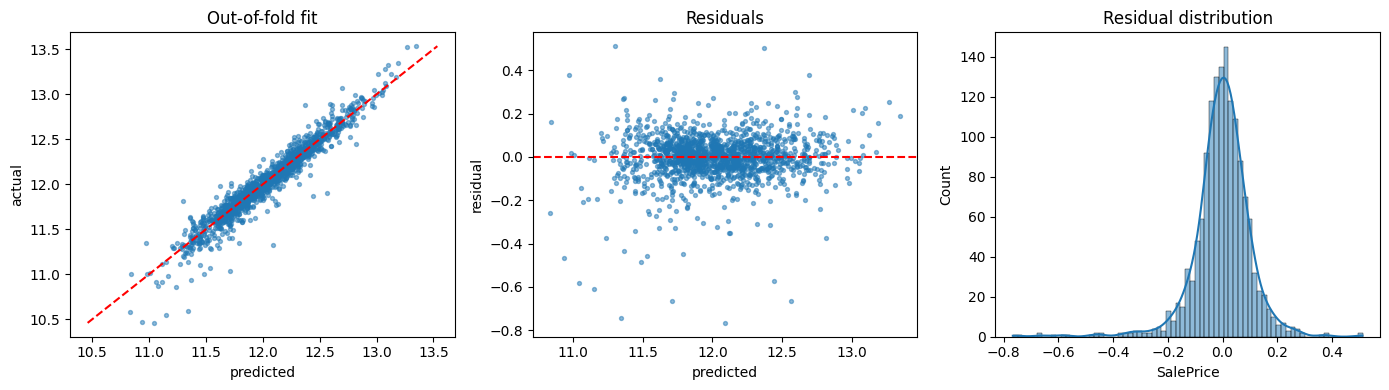

In [ ]:
resid = y - blend_oof

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(blend_oof, y, s=8, alpha=0.5)
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--")
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual"); ax[0].set_title("Out-of-fold fit")

ax[1].scatter(blend_oof, resid, s=8, alpha=0.5); ax[1].axhline(0, c="r", ls="--")
ax[1].set_xlabel("predicted"); ax[1].set_ylabel("residual"); ax[1].set_title("Residuals")

sns.histplot(resid, kde=True, ax=ax[2]); ax[2].set_title("Residual distribution")
plt.tight_layout()

print(f"R2 on the log scale     : {r2_score(y, blend_oof):.3f}")
print(f"median error in dollars : {np.median(np.abs(np.exp(y) - np.exp(blend_oof))):,.0f}")

In [ ]:
worst = resid.abs().sort_values(ascending=False).head(8).index
train_kept.loc[worst, ["Id", "GrLivArea", "OverallQual", "SaleCondition", "SalePrice"]].assign(
    predicted=np.exp(blend_oof[worst]).round(0)
)

,Id,GrLivArea,OverallQual,SaleCondition,SalePrice,predicted
631,633,1411,7,Family,82500,177588.0
30,31,1317,4,Normal,40000,84308.0
462,463,864,5,Normal,62383,121636.0
1322,1325,1795,8,Partial,147000,286462.0
967,969,968,3,Abnorml,37900,69745.0
495,496,720,4,Abnorml,34900,62599.0
587,589,1473,5,Partial,143000,253512.0
969,971,1192,4,Abnorml,135000,80935.0


## 6.4 What the models use

*To write: the linear model and the tree model agree on the top handful, which suggests the signal is real rather than an artefact of one algorithm. Do not read individual coefficients too closely — section 2.4 showed the columns are collinear, so credit for an effect can move between them.*

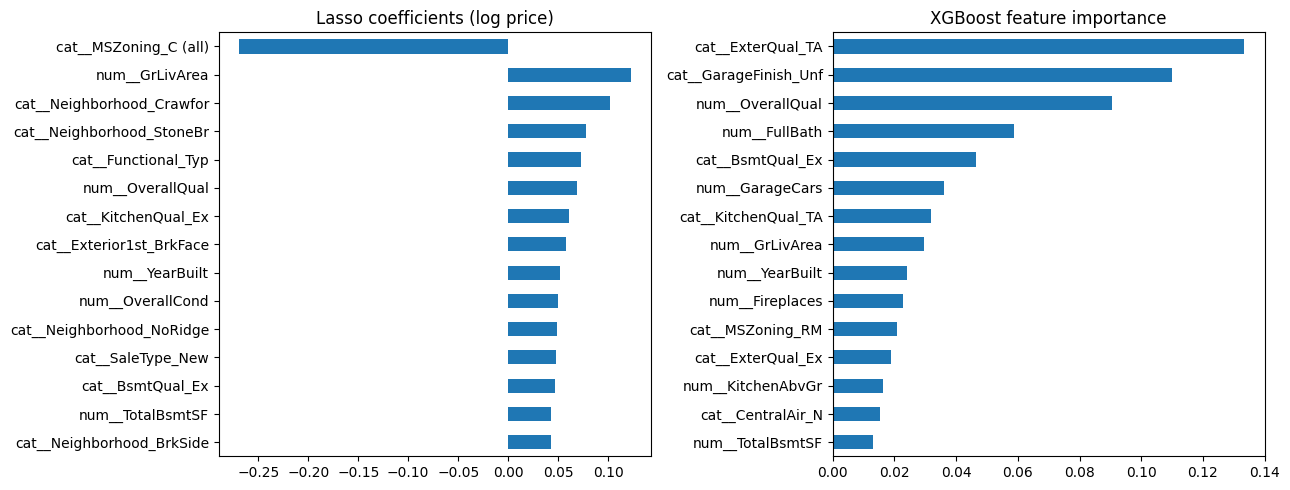

In [ ]:
xgb_fit = make_pipe(xgb).fit(X, y)
names = lasso_fit.named_steps["pre"].get_feature_names_out()

lasso_top = pd.Series(lasso_coefs, index=names)
lasso_top = lasso_top[lasso_top != 0].sort_values(key=abs, ascending=False).head(15)
xgb_top = pd.Series(xgb_fit.named_steps["model"].feature_importances_, index=names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
lasso_top.iloc[::-1].plot(kind="barh", ax=ax[0], title="Lasso coefficients (log price)")
xgb_top.iloc[::-1].plot(kind="barh", ax=ax[1], title="XGBoost feature importance")
plt.tight_layout()

# 7. Kaggle submission

## 7.1 Submission log

Our submissions, sorted by the public leaderboard — the only score measured on houses no part of our process has seen. "Config" names which pipeline produced it, because we changed the pipeline twice and the scores are not otherwise comparable.

| Submitted | Config | Public LB | CV RMSE |
| --- | --- | --- | --- |
| Five models, with the network | ordinal encoding, long training | **0.12310** | 0.1076 |
| Four models | Box-Cox + engineered features | 0.12315 | 0.1068 |
| Five models, with the network | ordinal encoding, short training | 0.12325 | 0.1083 |
| Five models, with the network | blunt rule, long training | 0.12327 | 0.1072 |
| Four models | ordinal encoding, long training | 0.12354 | 0.1068 |
| **Four models** *(shipped)* | **blunt rule, long training** | **0.12376** | **0.1065** |
| Four models | ordinal encoding, short training | 0.12377 | 0.1076 |
| 0.4 SVR / 0.4 XGB / 0.2 Lasso | ordinal encoding, short training | 0.12381 | 0.1078 |
| Lasso + XGBoost only | earliest version | 0.12447 | 0.1086 |
| SVR alone | blunt rule, long training | 0.12527 | 0.1106 |
| Lasso + XGBoost, tuned on one split | earliest version | 0.12540 | 0.1080 |
| SVR alone | ordinal encoding, short training | 0.12644 | 0.1112 |
| Neural network alone | ordinal encoding, short training | 0.12660 | 0.1162 |
| Lasso alone | blunt rule, long training | 0.12702 | 0.1099 |
| Lasso alone | ordinal encoding, short training | 0.12813 | 0.1124 |
| GradientBoosting alone | ordinal encoding, short training | 0.13063 | 0.1159 |
| OLS alone | blunt rule, long training | *pending* | 0.1302 |
| GradientBoosting alone | blunt rule, long training | *pending* | 0.1129 |
| 0.4 SVR / 0.4 XGB / 0.2 Lasso | blunt rule, long training | *pending* | 0.1068 |
| XGBoost alone | ordinal encoding, short training | 0.13089 | 0.1141 |
| XGBoost alone | blunt rule, long training | 0.13212 | 0.1138 |
| OLS alone | ordinal encoding, short training | 0.13626 | 0.1317 |

*To write:*
- *averaging is the only difference here large enough to trust: the shipped blend beats the best single model by 0.0015 out of sample*
- *three rows are still pending — two single models and the weighted variant. Fill them in before the report is final; the comparison in 6.1 depends on the weighted one.*
- *regularisation is worth 0.0081 on the one like-for-like pair we have — OLS at 0.13626 against Lasso at 0.12813, both on the same pipeline*
- *the whole table spans 0.0132, and everything above the OLS row spans 0.0090. We reached a plateau early and spent most of the project establishing that.*

### How we got here

| # | What changed | Public LB |
| --- | --- | --- |
| 1 | first working blend, Lasso + XGBoost with settings chosen by hand | 0.12447 |
| 2 | tuned XGBoost against a single 20% validation split | **0.12540** |
| 3 | tuning moved to 5-fold CV; added SVR and Huber gradient boosting | 0.12315 |
| 4 | dropped the engineered features and the Box-Cox transform | 0.12377 |
| 5 | added a neural network to the average | 0.12325 |
| 6 | trained the boosters longer, finer penalty and kernel grids | **0.12310** |
| 7 | replaced 52 lines of cleaning and ordinal encoding with one blunt rule | 0.12327 |
| 8 | dropped the neural network — four models, 263 lines of code | 0.12376 |

*To write — this is the refinement narrative the report asks for:*
- *submission 2 is the one worth presenting: it scored better than submission 1 in our own cross-validation and 0.0009 worse on the leaderboard. Single-split tuning fitted the noise in 292 particular rows. Everything after it was tuned on 5-fold CV.*
- *submissions 7 and 8 cost 0.0007 between them and were both deliberate: simpler cleaning, and one fewer model. Say plainly that we traded a little accuracy for a notebook we can defend.*
- *submission 1 to submission 8 is 0.0007 of leaderboard across eight submissions. The models were never the bottleneck.*
- *do not over-read anything below the third decimal: submission 4 scored the same twice from separate runs, so the pipeline is reproducible but the fourth decimal is not*

## 7.2 Building the files

The models are refitted on all 1,458 rows. We write the four-model average, the hand-weighted variant, and each blended model on its own as a control — cross-validation and the leaderboard are scored on different houses, so the controls are there to check whether they agree. Ridge is not written: it is not in the blend.

In [ ]:
ols_fit = make_pipe(LinearRegression()).fit(X, y)
svr_fit = make_pipe(svr).fit(X, y)
gbr_fit = make_pipe(gbr).fit(X, y)

test_preds = {"OLS": ols_fit.predict(X_test), "Lasso": lasso_fit.predict(X_test),
              "SVR": svr_fit.predict(X_test), "XGBoost": xgb_fit.predict(X_test),
              "GradientBoosting": gbr_fit.predict(X_test)}


cv = results.set_index("model").cv_rmse

# the equal average, and the hand-weighted alternative from section 6.1
blend = np.mean([test_preds[m] for m in picks], axis=0)

weights = {"SVR": 0.4, "XGBoost": 0.4, "Lasso": 0.2}
weighted = sum(w * test_preds[m] for m, w in weights.items())
weighted_rmse = np.sqrt(mean_squared_error(y, sum(w * models[m] for m, w in weights.items())))

# each model on its own, as a control
filenames = {"OLS": "ols", "Lasso": "lasso", "SVR": "svr",
             "XGBoost": "xgboost", "GradientBoosting": "gbr"}

files = [("submission_blend.csv", blend, blend_rmse),
         ("submission_blend_weighted.csv", weighted, weighted_rmse)]
for m, short in filenames.items():
    files.append((f"submission_{short}.csv", test_preds[m], cv[m]))

for name, pred, _ in files:
    pd.DataFrame({"Id": test_ids, "SalePrice": np.exp(pred)}).to_csv(name, index=False)

pd.DataFrame([{"file": n, "cv_rmse": score} for n, _, score in files]).round(4)

,file,cv_rmse
0,submission_blend.csv,0.1065
1,submission_blend_weighted.csv,0.1068
2,submission_ols.csv,0.1302
3,submission_lasso.csv,0.1099
4,submission_svr.csv,0.1106
5,submission_xgboost.csv,0.1138
6,submission_gbr.csv,0.1129


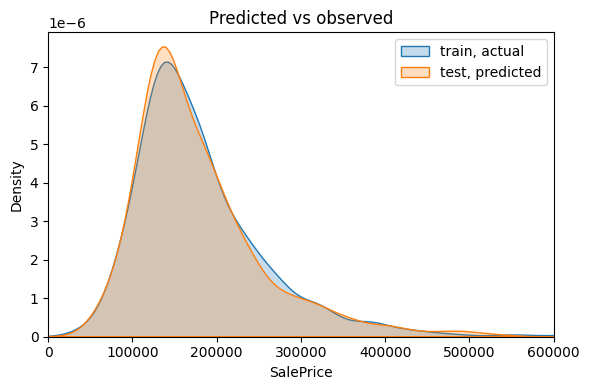

In [ ]:
# sanity check: predicted prices should look like the prices we trained on
plt.figure(figsize=(6, 4))
sns.kdeplot(np.exp(y), label="train, actual", fill=True)
sns.kdeplot(np.exp(blend), label="test, predicted", fill=True)
plt.xlim(0, 600000); plt.xlabel("SalePrice"); plt.legend()
plt.title("Predicted vs observed"); plt.tight_layout()

# 8. Conclusion

*To write:*
- *how well the model did: the leaderboard score, the typical error in dollars from section 6.3, and roughly where that sits among entrants*
- *the biggest lesson is about measurement. We believed removing two bad rows was our largest win until we scored it on the same houses both ways — see 6.2 for what it was actually worth. The first version of that comparison was measuring the outliers' own residuals.*
- *what actually moved the needle: sensible hyperparameters over library defaults, training the boosters long enough, and averaging models rather than choosing one (0.0015 confirmed out of sample)*
- *the running theme: our cross-validation and the leaderboard disagreed repeatedly, and every time cross-validation was the one rewarding extra flexibility — a model tuned on a single split, the neural network in the blend three times over, and the switch to one-hot encoding*
- *the structural reason: cross-validation trains on 80% of the rows and scores on data drawn the same way. It measures fit on familiar data, which is not generalisation, and it is systematically generous to whichever model has the most freedom.*
- *the data dictionary told us NA meant "no basement", not "unknown" — a domain fact no algorithm could recover on its own. Section 3 then showed the model did not need us to act on it, which is a second finding rather than a contradiction.*
- *eight submissions moved the leaderboard by 0.0007. Almost all of the accuracy was in place from the first working model.*
- *what we would do next: neighbourhood-level external data, target encoding, a stacked meta-learner instead of a plain average*
- *a closing sentence that ties it together*

**References**

- De Cock, D. (2011). Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester Regression Project. *Journal of Statistics Education*, 19(3).
- Kaggle, *House Prices - Advanced Regression Techniques*.